In [33]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#!pip install --force-reinstall scikit-learn
#!pip show scikit-learn

In [34]:
DATA_PATH = Path("/content/combined_output.csv")
MODEL_PATH = Path("/content/").parent / "logistic_regression_latest.joblib"
TARGET_COLUMN = "mitre_attack_tactics"
EXCLUDE_COLUMNS = {
    "dest_ip",
    "src_ip",
    "uid",
    "community_id",
    "datetime",
    "ts",
    "protocol",
}

In [35]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        # Check if the path is absolute and starts with '/', but not '/content/'
        # This handles cases where DATA_PATH is incorrectly defined as Path("/content/").parent / "..."
        if str(path).startswith('/') and not str(path).startswith('/content/'):
            corrected_path = Path("/content") / path.name
            if corrected_path.exists():
                print(f"Correcting data path from '{path}' to '{corrected_path}'")
                path = corrected_path
            else:
                raise FileNotFoundError(f"Data file not found: {path} and also not found at {corrected_path}")
        else:
            raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)
    print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns.")
    return df

In [36]:
def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    if TARGET_COLUMN not in df.columns:
        raise ValueError(f"Target column '{TARGET_COLUMN}' not found in input CSV.")

    df = df.copy()
    excluded_actual = EXCLUDE_COLUMNS.intersection(df.columns)
    df = df.drop(columns=excluded_actual, errors="ignore")
    df = df.dropna(subset=[TARGET_COLUMN])

    y = df[TARGET_COLUMN].astype(str).copy()
    X = df.drop(columns=[TARGET_COLUMN])

    # Convert values that look numeric into numeric columns.
    for col in X.columns:
        if X[col].dtype == object:
            converted = pd.to_numeric(X[col], errors="coerce")
            if converted.notna().sum() > len(X) * 0.75:
                X[col] = converted

    # --- Feature Engineering: Create new features ---
    # Total packets and bytes
    X['total_pkts'] = X['orig_pkts'] + X['resp_pkts']
    X['total_bytes'] = X['orig_bytes'] + X['resp_bytes']

    # Packet and byte ratios (handling division by zero)
    X['pkt_ratio'] = X['resp_pkts'] / X['total_pkts'].replace(0, np.nan)
    X['byte_ratio'] = X['resp_bytes'] / X['total_bytes'].replace(0, np.nan)
    X[['pkt_ratio', 'byte_ratio']] = X[['pkt_ratio', 'byte_ratio']].fillna(0) # Fill NaN from 0/0 with 0

    # Packet and byte rates (handling division by zero and infinite values)
    X['pkt_rate'] = X['total_pkts'] / X['duration'].replace(0, np.nan)
    X['byte_rate'] = X['total_bytes'] / X['duration'].replace(0, np.nan)
    # Fill NaN and inf values that arise from division by zero duration with 0
    X[['pkt_rate', 'byte_rate']] = X[['pkt_rate', 'byte_rate']].replace([np.inf, -np.inf], 0).fillna(0)
    # --- End Feature Engineering ---

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

    if categorical_features:
        X[categorical_features] = X[categorical_features].fillna("missing")

    print("Using numeric features:", numeric_features)
    print("Using categorical features:", categorical_features)

    if not numeric_features and not categorical_features:
        raise ValueError("No valid features found for training.")

    # Added summary for explanation
    print("\n--- Feature Summary ---")
    print(f"Target column: {TARGET_COLUMN}")
    print(f"Columns explicitly excluded: {list(excluded_actual)}")
    print(f"Final set of numeric features used: {numeric_features}")
    print(f"Final set of categorical features used: {categorical_features}")
    print("-----------------------")

    return X, y, numeric_features, categorical_features

In [37]:
def build_pipeline(numeric_features: list[str], categorical_features: list[str]) -> Pipeline:
    transformers = []

    if numeric_features:
        numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("numeric", numeric_transformer, numeric_features))

    if categorical_features:
        categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        transformers.append(("categorical", categorical_transformer, categorical_features))

    column_transformer = ColumnTransformer(transformers=transformers, remainder="drop")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", column_transformer),
            (
                "classifier",
                LogisticRegression(
                    solver="saga",
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    return pipeline

In [38]:
# This variable is already available in the kernel from previous execution.
# It contains the names of the features after preprocessing (imputation, scaling, and one-hot encoding).
print("Features after encoding and feature engineering:")
print(feature_names_transformed.tolist())

Features after encoding and feature engineering:
['numeric__resp_pkts', 'numeric__orig_ip_bytes', 'numeric__missed_bytes', 'numeric__duration', 'numeric__orig_pkts', 'numeric__resp_ip_bytes', 'numeric__dest_port', 'numeric__orig_bytes', 'numeric__resp_bytes', 'numeric__src_port', 'numeric__total_pkts', 'numeric__total_bytes', 'numeric__pkt_ratio', 'numeric__byte_ratio', 'numeric__pkt_rate', 'numeric__byte_rate', 'categorical__service_dhcp', 'categorical__service_dns', 'categorical__service_missing', 'categorical__service_ntp', 'categorical__service_radius', 'categorical__local_resp_False', 'categorical__local_resp_True', 'categorical__protocol_icmp', 'categorical__protocol_tcp', 'categorical__protocol_udp', 'categorical__conn_state_OTH', 'categorical__conn_state_RSTO', 'categorical__conn_state_S0', 'categorical__conn_state_S1', 'categorical__conn_state_SF', 'categorical__conn_state_SHR', 'categorical__local_orig_False', 'categorical__local_orig_True', 'categorical__history_D', 'categor

In [39]:
def plot_results(y_test: pd.Series, y_pred: np.ndarray, labels: list[str]) -> None:
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 14))

    actual_counts = [np.sum(y_test == label) for label in labels]
    predicted_counts = [np.sum(y_pred == label) for label in labels]
    x = np.arange(len(labels))
    width = 0.35

    axes[0].bar(x - width / 2, actual_counts, width, label="Actual")
    axes[0].bar(x + width / 2, predicted_counts, width, label="Predicted")
    axes[0].set_title("Class distribution: actual vs predicted")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.4)

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[1], cmap=plt.cm.Blues, xticks_rotation=45)
    axes[1].set_title("Confusion Matrix")

    fig.tight_layout()
    plt.show()

In [40]:
def main() -> None:
    df = load_data(DATA_PATH)
    X, y, numeric_features, categorical_features = prepare_features(df)

    if X.empty or y.empty:
        raise ValueError("No data available after preprocessing.")

    stratify = y if y.value_counts().min() >= 2 else None
    if stratify is None:
        print("Warning: stratified split disabled because some classes have fewer than 2 samples.")

    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify,
    )

    pipeline = build_pipeline(numeric_features, categorical_features)

    print("Training Logistic Regression model...")
    pipeline.fit(x_train, y_train)

    print("Evaluating model...")
    y_pred = pipeline.predict(x_test)
    print(classification_report(y_test, y_pred, zero_division=0))

    try:
        import joblib

        joblib.dump(pipeline, MODEL_PATH)
        print(f"Saved trained model to {MODEL_PATH}")
    except ImportError:
        print("joblib not installed; skipping model persistence.")

    labels = sorted(y.unique())
    plot_results(y_test, y_pred, labels)


Loaded 79,263 rows and 23 columns.
Using numeric features: ['resp_pkts', 'orig_ip_bytes', 'missed_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
Using categorical features: ['service', 'local_resp', 'conn_state', 'local_orig', 'history']

--- Feature Summary ---
Target column: mitre_attack_tactics
Columns explicitly excluded: ['ts', 'community_id', 'dest_ip', 'datetime', 'src_ip', 'protocol', 'uid']
Final set of numeric features used: ['resp_pkts', 'orig_ip_bytes', 'missed_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
Final set of categorical features used: ['service', 'local_resp', 'conn_state', 'local_orig', 'history']
-----------------------
Training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Evaluating model...
                precision    recall  f1-score   support

Reconnaissance       0.81      0.97      0.88      3613
          none       0.99      0.93      0.96     12240

      accuracy                           0.94     15853
     macro avg       0.90      0.95      0.92     15853
  weighted avg       0.95      0.94      0.94     15853

Saved trained model to /logistic_regression_latest.joblib


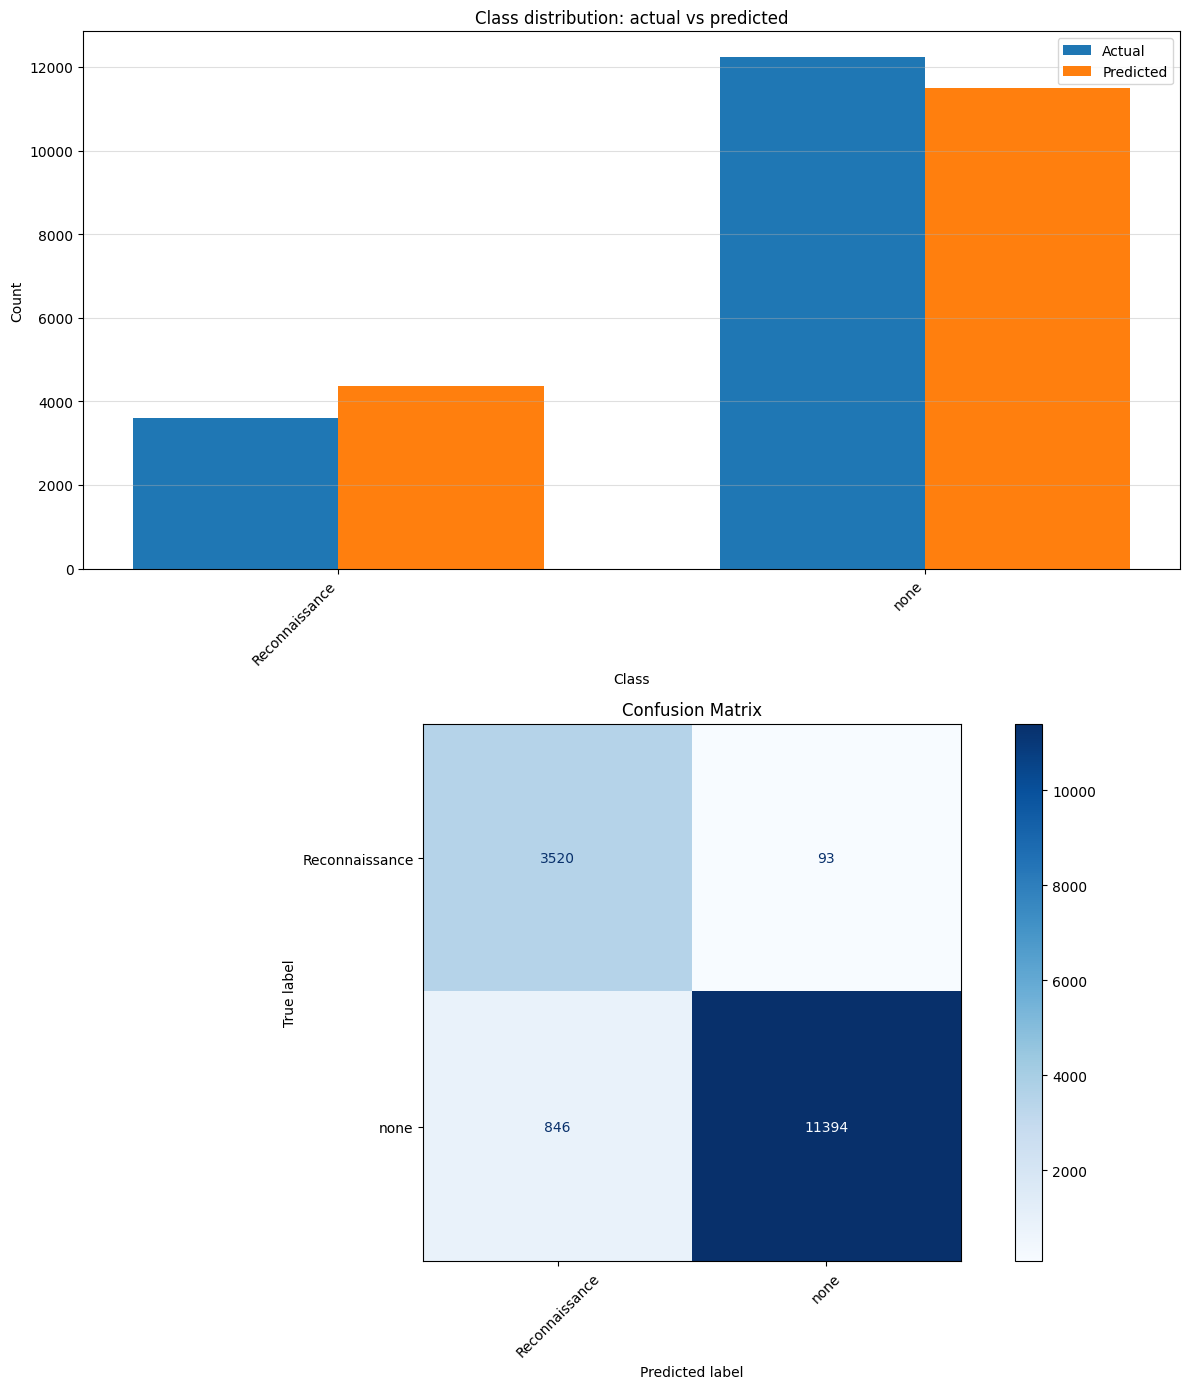

In [41]:
if __name__ == "__main__":
    main()

In [42]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained pipeline
print(f"Loading model from {MODEL_PATH}")
pipeline_loaded = joblib.load(MODEL_PATH)

# Access the trained classifier and preprocessor
classifier = pipeline_loaded.named_steps['classifier']
preprocessor = pipeline_loaded.named_steps['preprocessor']

# Get feature names after preprocessing
# For ColumnTransformer, get_feature_names_out() provides the full list of transformed feature names
feature_names_transformed = preprocessor.get_feature_names_out()

# Get coefficients from the logistic regression model
# For binary classification, coef_ is a 2D array (n_classes, n_features), so we take the first (and only) row
coefficients = classifier.coef_[0]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_transformed,
    'Importance': coefficients
})

# Determine which class corresponds to the positive coefficients
# The coefficients correspond to the positive class in a binary classification setup
positive_class_label = classifier.classes_[1] # Typically, sklearn orders classes alphabetically or by appearance
negative_class_label = classifier.classes_[0]

print(f"Model classes: {classifier.classes_}")
print(f"Positive coefficients indicate importance for class: '{positive_class_label}'")
print(f"Negative coefficients indicate importance for class: '{negative_class_label}'")

# Sort by absolute importance to see the most influential features overall
feature_importance_df['Absolute Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute Importance', ascending=False)

# Display the top 20 most important features
display(feature_importance_df.head(20))


Loading model from /logistic_regression_latest.joblib
Model classes: ['Reconnaissance' 'none']
Positive coefficients indicate importance for class: 'none'
Negative coefficients indicate importance for class: 'Reconnaissance'


,Feature,Importance,Absolute Importance
12,numeric__pkt_ratio,-14.562544,14.562544
28,categorical__conn_state_SHR,13.734174,13.734174
37,categorical__history_^d,13.734174,13.734174
6,numeric__dest_port,12.424577,12.424577
8,numeric__resp_bytes,-10.198434,10.198434
38,categorical__history_missing,-10.167181,10.167181
23,categorical__conn_state_OTH,-10.167181,10.167181
5,numeric__resp_ip_bytes,7.282963,7.282963
16,categorical__service_dhcp,7.247711,7.247711
18,categorical__service_missing,-7.177912,7.177912


/tmp/ipykernel_6354/1441458927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


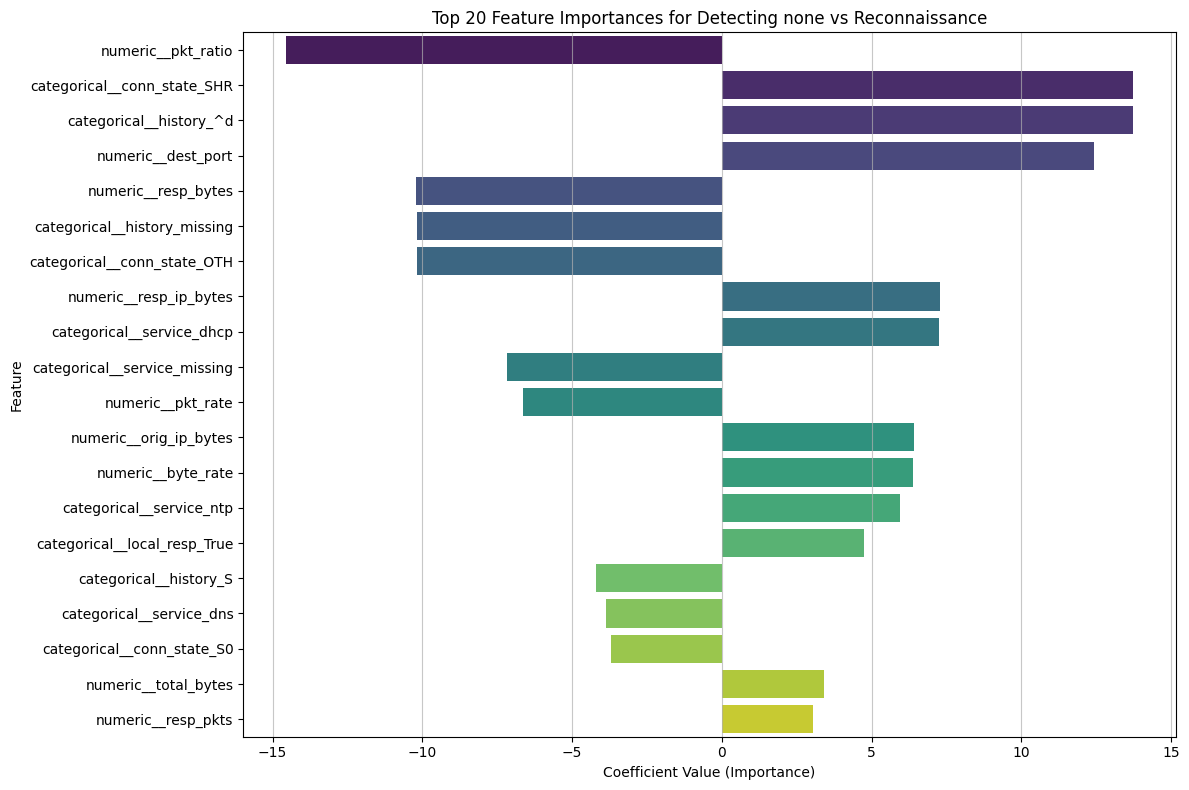

In [43]:
# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title(f'Top 20 Feature Importances for Detecting {positive_class_label} vs {negative_class_label}')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.7)
plt.tight_layout()
plt.show()


In [44]:
print(feature_importance_df['Feature'].unique().tolist())

['numeric__pkt_ratio', 'categorical__conn_state_SHR', 'categorical__history_^d', 'numeric__dest_port', 'numeric__resp_bytes', 'categorical__history_missing', 'categorical__conn_state_OTH', 'numeric__resp_ip_bytes', 'categorical__service_dhcp', 'categorical__service_missing', 'numeric__pkt_rate', 'numeric__orig_ip_bytes', 'numeric__byte_rate', 'categorical__service_ntp', 'categorical__local_resp_True', 'categorical__history_S', 'categorical__service_dns', 'categorical__conn_state_S0', 'numeric__total_bytes', 'numeric__resp_pkts', 'numeric__duration', 'numeric__orig_pkts', 'categorical__local_resp_False', 'numeric__byte_ratio', 'numeric__orig_bytes', 'categorical__local_orig_False', 'categorical__conn_state_SF', 'categorical__history_Sh', 'categorical__conn_state_S1', 'categorical__history_Dd', 'categorical__history_ShADadFf', 'categorical__history_D', 'numeric__total_pkts', 'numeric__src_port', 'categorical__history_ShR', 'categorical__conn_state_RSTO', 'categorical__local_orig_True', '

The bar plot above visualizes the top 20 most influential features according to the Logistic Regression model. The length and direction of the bars indicate the magnitude and direction of their impact on the log-odds of a connection belonging to the `Reconnaissance` class (assuming `Reconnaissance` is the positive class as indicated by `classifier.classes_[1]`).

*   **Positive coefficients** indicate that an increase in the feature value makes the model more likely to predict `Reconnaissance`.
*   **Negative coefficients** indicate that an increase in the feature value makes the model less likely to predict `Reconnaissance` (i.e., more likely to predict `none`).

This plot helps us identify key indicators or patterns that the model learned are associated with `Reconnaissance` activities versus normal traffic (`none`).

Loaded 79,263 rows and 23 columns.


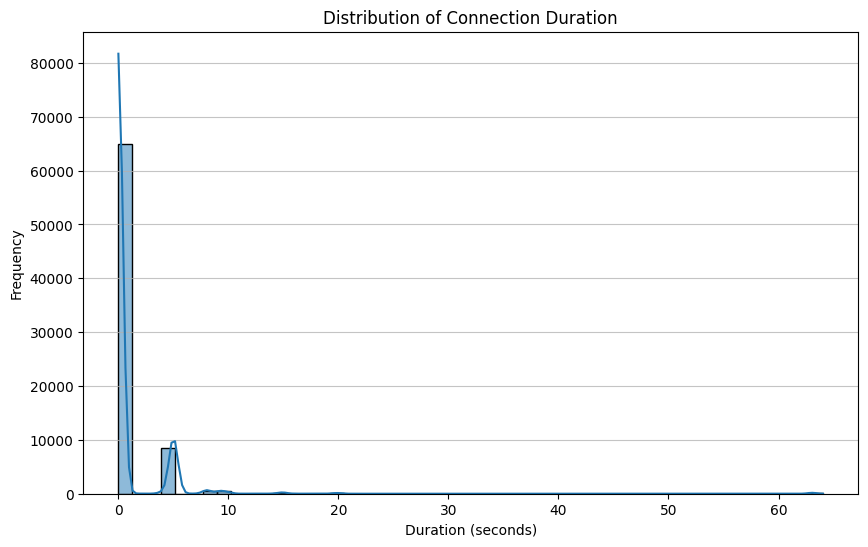

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_for_plot is defined for visualization
df_for_plot = load_data(DATA_PATH)

# Plot 1: Histogram of 'duration'
plt.figure(figsize=(10, 6))
sns.histplot(df_for_plot['duration'], bins=50, kde=True)
plt.title('Distribution of Connection Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

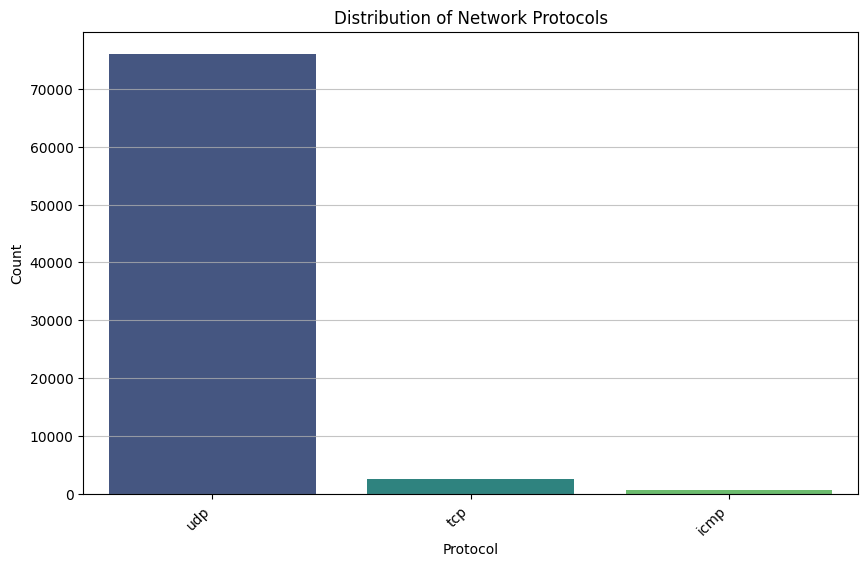

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 2: Count plot for 'protocol'
plt.figure(figsize=(10, 6))
sns.countplot(data=df_for_plot, x='protocol', hue='protocol', palette='viridis', legend=False)
plt.title('Distribution of Network Protocols')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

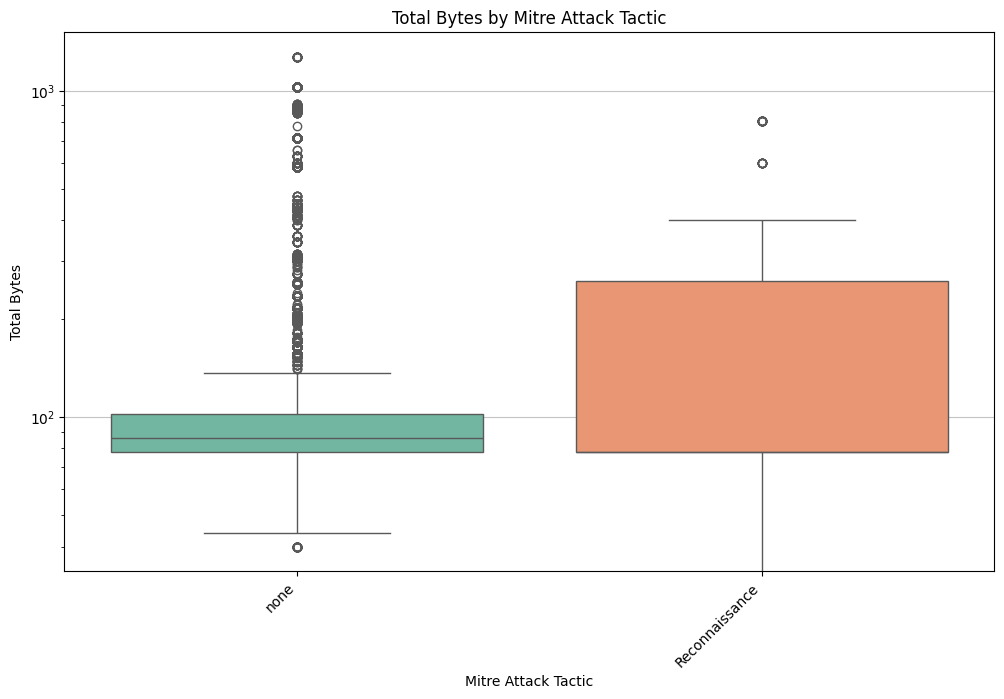

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 3: Box plot of 'total_bytes' by 'mitre_attack_tactics'
# Create 'total_bytes' for visualization if not already present in df_for_plot
# Note: This was created in the prepare_features function on X, not necessarily df_for_plot
# We need to re-create it here for plotting if df_for_plot is the original raw data.
# For simplicity, let's assume df_for_plot is the one from which features can be derived or it has it.
# If not, a re-run of prepare_features on df_for_plot would be needed to get 'total_bytes'.

# Let's create a temporary DataFrame to get 'total_bytes' correctly for plotting
# We'll use the logic from prepare_features to ensure consistency
temp_df = df_for_plot.copy()
temp_df['total_bytes'] = temp_df['orig_bytes'] + temp_df['resp_bytes']

plt.figure(figsize=(12, 7))
sns.boxplot(data=temp_df, x=TARGET_COLUMN, y='total_bytes', hue=TARGET_COLUMN, palette='Set2', legend=False)
plt.title('Total Bytes by Mitre Attack Tactic')
plt.xlabel('Mitre Attack Tactic')
plt.ylabel('Total Bytes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.yscale('log') # Use log scale for y-axis if total_bytes has a wide range
plt.show()

Reloading data for visualization...
Loaded 79,263 rows and 23 columns.


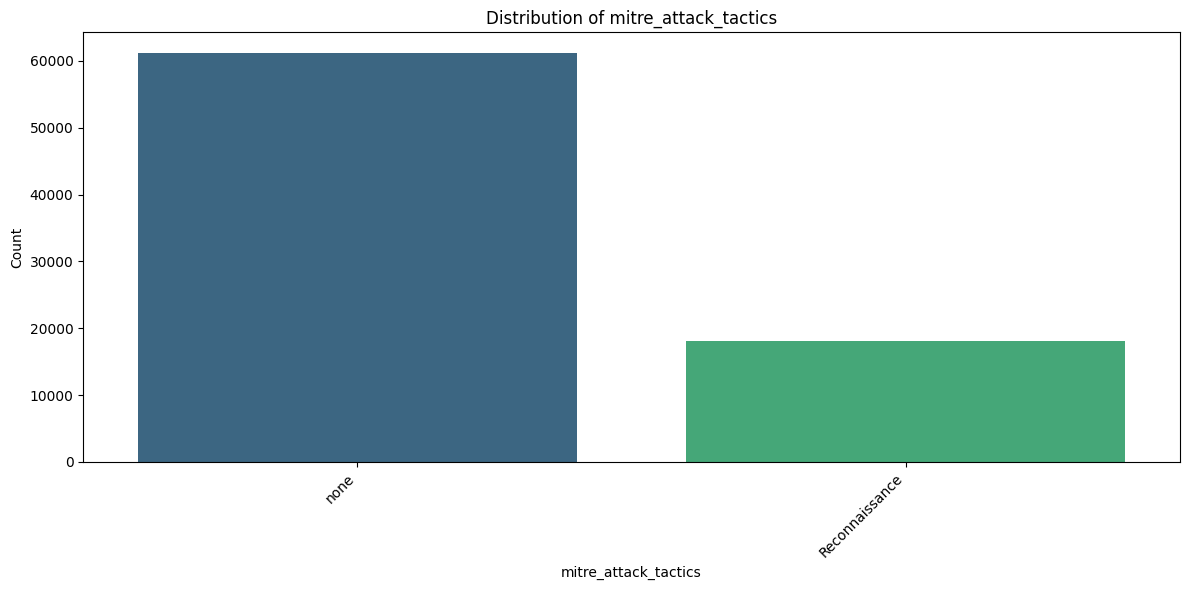

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is available from the main function's execution
# If df is not directly available in the global scope, we'd need to re-run the data loading part.
# For now, let's assume it is or can be reloaded.

# Let's reload df just to be safe if this cell is run independently.
# This re-executes the data loading step, which is efficient for this purpose.
print("Reloading data for visualization...")
df_for_plot = load_data(DATA_PATH)

# Get value counts for the target variable 'mitre_attack_tactics'
event_id_counts = df_for_plot[TARGET_COLUMN].value_counts()

# Filter out classes with very few samples if there are too many unique event_ids
# to make the plot readable. Let's show the top 20 most frequent event_ids.
top_n = 20
if len(event_id_counts) > top_n:
    event_id_counts_display = event_id_counts.head(top_n)
    other_count = event_id_counts.iloc[top_n:].sum()
    event_id_counts_display['Other'] = other_count
else:
    event_id_counts_display = event_id_counts

plt.figure(figsize=(12, 6))
sns.barplot(x=event_id_counts_display.index, y=event_id_counts_display.values, hue=event_id_counts_display.index, palette='viridis', legend=False)
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
from google.colab import files

try:
    # Assuming MODEL_PATH is defined and points to your joblib file
    # Make sure this path is correct and accessible.
    files.download(str(MODEL_PATH))
    print(f"Downloading {MODEL_PATH}...")
except FileNotFoundError:
    print(f"Error: The file {MODEL_PATH} was not found. Please ensure the model has been saved.")
except Exception as e:
    print(f"An error occurred during download: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>